In [1]:
from pathlib import Path 

import cv2
import IPython
import numpy as np
import pandas as pd
from retinaface import RetinaFace
import plotly.express as px

2024-06-02 15:19:33.244832: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-02 15:19:33.941128: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [3]:
def draw_faces(image, faces):
    for face, data in faces.items():
        # バウンディングボックス
        x1, y1, x2, y2 = data['facial_area']
        color = (0, 0, 255)
        thickness = 2
        cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)
    show_image(image)

In [4]:
def box_from_row(row):
    return [int(x) for x in (row['x1'], row['y1'], row['x2'], row['y2'])]

In [5]:
def draw_box(image, box):
    x1, y1, x2, y2 = box
    color = (0, 0, 255)
    thickness = 2
    cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)
    show_image(image)

In [6]:
def get_by_id(id):
    faces = pd.read_csv('../data/faces.csv', index_col=0)
    fp = Path('../test_images').joinpath(faces.iloc[id]['name'])
    print(fp.name)
    img = cv2.imread(str(fp))
    return img

In [7]:
def show_by_id(id):
    img = get_by_id(id)
    show_image(img)

In [8]:
def show_by_name(name):
    fp = Path('../test_images').joinpath(name)
    img = cv2.imread(str(fp))
    show_image(img)

In [9]:
def get_center(box):
    center_x = int((box['x2'] - box['x1'])/2) + box['x1']
    center_y = int((box['y2'] - box['y1'])/2) + box['y1']
    return (center_x, center_y)

In [10]:
def check_center(row):
    center = get_center(row)
    box = row[['x1_ground', 'y1_ground', 'x2_ground', 'y2_ground']].to_frame().transpose().rename({'x1_ground': 'x1',
                                                                            'y1_ground': 'y1',
                                                                            'x2_ground': 'x2',
                                                                            'y2_ground': 'y2'},
                                                                            axis=1).to_dict(orient='list')
    center_ground = get_center({k: v[0] for k, v in box.items()})
    return center, center_ground

In [32]:
def show_heatmap(df):
    g = df[['status', 'name']].groupby('status').count()
    d = {'tp': round(g.loc['tp'].item()/g['name'].sum(), 3),
         'fp': round(g.loc['fp'].item()/g['name'].sum(), 3),
         'fn': round(g.loc['fn'].item()/g['name'].sum(), 3),
         'tn': round(g.loc['tn'].item()/g['name'].sum(), 3)}
    a = [[d['tp'], d['fp']], [d['fn'], d['tn']]]
    text = [[f'True Positive: {d["tp"]} ({g.loc["tp"].item()}/{g["name"].sum()})',
             f'False Positive: {d["fp"]} ({g.loc["fp"].item()}/{g["name"].sum()})'],
            [f'False Negative: {d["fn"]} ({g.loc["fn"].item()}/{g["name"].sum()})',
             f'True Negative: {d["tn"]} ({g.loc["tn"].item()}/{g["name"].sum()})']]
    fig = px.imshow(a, 
                    x=['positive', 'negative'],
                    y=['positive', 'negative'],
                    labels={'y': 'Predicted', 'x': 'Actual'})
    fig.update_traces(text=text, texttemplate="%{text}")
    fig.show()   

In [12]:
faces_df = pd.read_csv('../data/faces.csv', index_col=0)
faces_df.head()

,name,img_height,img_width,x1,y1,x2,y2,width,height,area,pct_of_frame,face_num
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,1080,1920,323,5,919,731,596,726,432696,0.208669,0
1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,1080,1920,262,42,614,507,352,465,163680,0.078935,0
2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080,1920,484,389,671,617,187,228,42636,0.020561,0
3,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080,1920,1003,42,1195,261,192,219,42048,0.020278,1
4,Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,1080,1920,1121,66,1662,824,541,758,410078,0.197761,0


In [57]:
faces_df[faces_df['x1'].isna()]

,name,img_height,img_width,x1,y1,x2,y2,width,height,area,pct_of_frame,face_num


In [13]:
images = pd.DataFrame([{'name': x.name} for x in Path('../test_images').iterdir()])
images.head()

,name
0,Frasier.S08E01-E02.And.the.Dish.Ran.Away.with....
1,Silo.S01E09.The.Getaway.2160p.ATVP.WEB-DL.DDP5...
2,Will.&.Grace.S03E24.Sons.and.Lovers.Part.I.480...
3,Suits.S03E05.1080p.BluRay.x265-RARBG_40416.png
4,Will.&.Grace.S05E24.Season.Finale.480p.Web.h26...


In [15]:
negative = images[~images['name'].isin(faces_df['name'])]
negative.head()

,name
5,Frasier.S03E07.The.Adventures.of.Bad.Boy.and.D...
6,Fringe.S03E02.The.Box.1080p.BluRay.10bit.x265....
16,Seinfeld.S03E18.1080p.WEBRip.x265-RARBG_06960.png
17,Scrubs S05E03 My Day at the Races [1080p x265...
22,Cheers.S10E23.1080p.BluRay.x265-RARBG_23184.png


In [16]:
retina_df = pd.read_csv('../data/test.csv', index_col=0)
retina_df.head()

,x1,y1,x2,y2,width,height,area,confidence,face_num,img_width,img_height,pct_of_frame,name,duration
0,785.0,44.0,1134.0,488.0,349.0,444.0,154956.0,0.996000,0.0,1920.0,1080.0,0.074728,Frasier.S08E01-E02.And.the.Dish.Ran.Away.with....,15.101
1,1344.0,364.0,2002.0,1284.0,658.0,920.0,605360.0,0.998255,0.0,3840.0,1920.0,0.082107,Silo.S01E09.The.Getaway.2160p.ATVP.WEB-DL.DDP5...,1.692
2,266.0,76.0,368.0,217.0,102.0,141.0,14382.0,0.999093,0.0,640.0,480.0,0.046816,Will.&.Grace.S03E24.Sons.and.Lovers.Part.I.480...,1.283
3,554.0,70.0,634.0,236.0,80.0,166.0,13280.0,0.997544,1.0,640.0,480.0,0.043229,Will.&.Grace.S03E24.Sons.and.Lovers.Part.I.480...,1.283
4,370.0,176.0,799.0,800.0,429.0,624.0,267696.0,0.999574,0.0,1920.0,1080.0,0.129097,Suits.S03E05.1080p.BluRay.x265-RARBG_40416.png,0.160


In [17]:
retina_negative = retina_df[retina_df['x1'].isna()]
retina_negative.head()

,x1,y1,x2,y2,width,height,area,confidence,face_num,img_width,img_height,pct_of_frame,name,duration
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Frasier.S03E07.The.Adventures.of.Bad.Boy.and.D...,0.139
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fringe.S03E02.The.Box.1080p.BluRay.10bit.x265....,0.273
25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Scrubs S05E03 My Day at the Races [1080p x265...,0.117
38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cheers.S10E23.1080p.BluRay.x265-RARBG_23184.png,0.118
51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Scrubs S04E01 My Old Friend's New Friend [108...,0.118


In [18]:
temp = negative[negative['name'].isin(retina_negative['name'])]
temp['name'].unique().tolist()

['Frasier.S03E07.The.Adventures.of.Bad.Boy.and.Dirty.Girl.2.1080p.BluRay.10Bit.Dts-HDMa2.0.HEVC-d3g_04920.png',
 'Fringe.S03E02.The.Box.1080p.BluRay.10bit.x265.HEVC.DD.5.1-PHOCiS_54600.png',
 'Scrubs S05E03 My Day at the Races  [1080p x265 10bit Joy]_00768.png',
 'Cheers.S10E23.1080p.BluRay.x265-RARBG_23184.png',
 'Fringe.S01E08.The.Equation.1080p.BluRay.10bit.x265.HEVC.DD.5.1-PHOCiS_60384.png',
 'Fringe.S02E18.White.Tulip.1080p.BluRay.10bit.x265.HEVC.DD.5.1-PHOCiS_08016.png',
 'The.X-Files.S09E05.Lord.of.the.Flies.1080p.BluRay.10Bit.Dts-HDMa5.1.HEVC-d3g_60864.png',
 'Modern.Family.S11E06.A.Game.of.Chicken.1080p.DSNP.WEB-DL.DDP5.1.H.264-WKS_13248.png',
 'The.X-Files.S10E05.Babylon.1080p.BluRay.10Bit.Dts-HDMa5.1.HEVC-d3g_50640.png',
 'Modern.Family.S07E14.The.Storm.1080p.DSNP.WEB-DL.DDP5.1.H.264-CRFW_20424.png',
 'Seinfeld.S04E02.1080p.WEBRip.x265-RARBG_29976.png',
 'Frasier.S11E08.Murder.Most.Maris.2.1080p.BluRay.10Bit.Dts-HDMa2.0.HEVC-d3g_00096.png',
 'Seinfeld.S05E07.1080p.WEBRip.x26

In [19]:
eph = negative[~negative['name'].isin(retina_negative['name'])]
eph['name'].unique().tolist()

['Seinfeld.S03E18.1080p.WEBRip.x265-RARBG_06960.png',
 'The.X-Files.S06E05.Dreamland.II.1080p.BluRay.10Bit.Dts-HDMa5.1.HEVC-d3g_00240.png',
 'Scrubs S06E09 My Perspective  [1080p x265 10bit Joy]_34200.png',
 'The.X-Files.S04E06.Sanguinarium.1080p.BluRay.10Bit.Dts-HDMa5.1.HEVC-d3g_29040.png',
 'Will.&.Grace.S03E08.Lows.in.the.Mid-Eighties.Part.I.480p.Web.h264-JBee_32568.png',
 'The.Leftovers.S02E05.BluRay.1080p.Dts.H265-d3g_13080.png',
 'Will.&.Grace.S05E05.Its.the.Gay.Pumpkin.Charlie.Brown.480p.Web.h264-JBee_33384.png',
 'Cheers.S08E05.1080p.BluRay.x265-RARBG_23304.png',
 'White.Collar.S06E01.1080p.WEBRip.x265-RARBG_57360.png',
 'The.X-Files.S01E04.Conduit.1080p.BluRay.10Bit.Dts-HDMa5.1.HEVC-d3g_12312.png',
 'Cheers.S09E21.1080p.BluRay.x265-RARBG_01776.png']

2024-06-02 15:19:51.152077: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-02 15:19:51.180927: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-02 15:19:51.181085: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

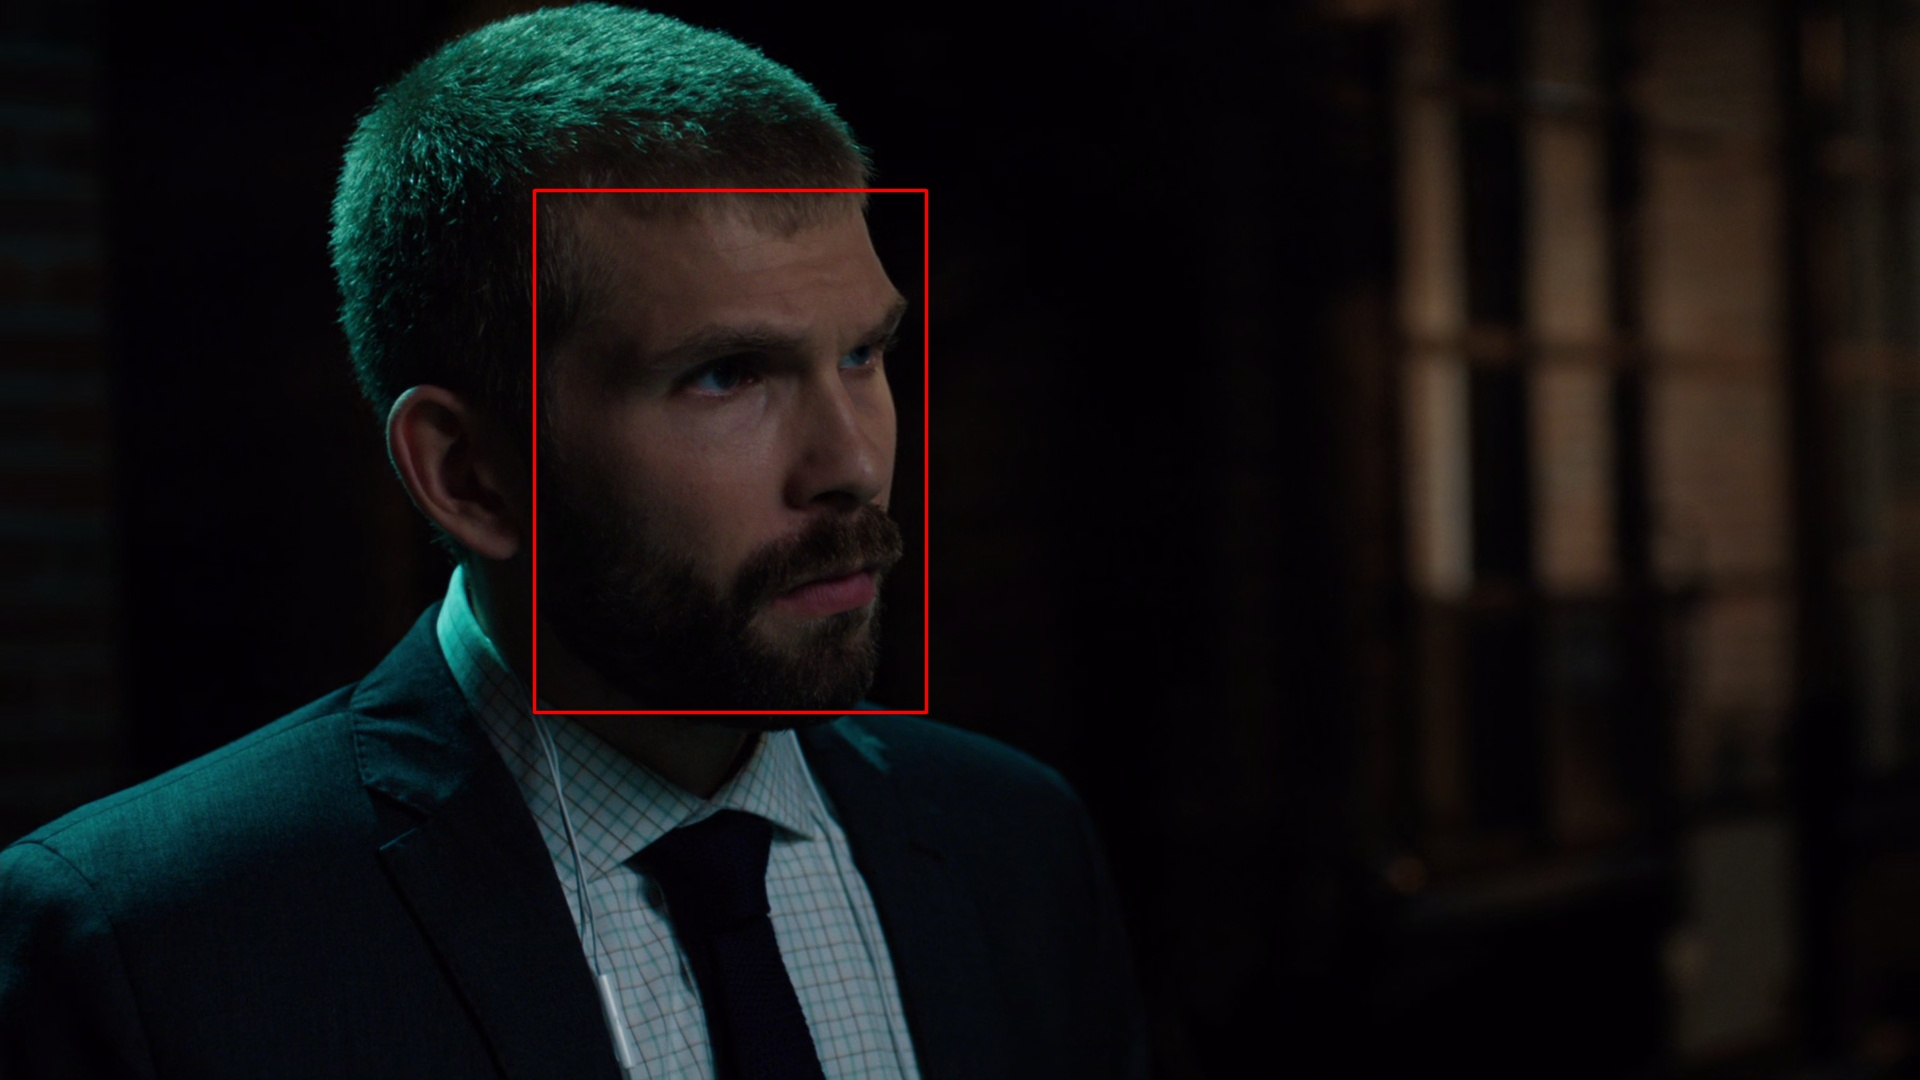

In [20]:
img = cv2.imread('../test_images/Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png')
faces = RetinaFace.detect_faces(img)
draw_faces(img, faces)

In [21]:
total_df = pd.concat([faces_df, negative], axis=0)
total_df.head()

,name,img_height,img_width,x1,y1,x2,y2,width,height,area,pct_of_frame,face_num
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,1080.0,1920.0,323.0,5.0,919.0,731.0,596.0,726.0,432696.0,0.208669,0.0
1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,1080.0,1920.0,262.0,42.0,614.0,507.0,352.0,465.0,163680.0,0.078935,0.0
2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080.0,1920.0,484.0,389.0,671.0,617.0,187.0,228.0,42636.0,0.020561,0.0
3,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080.0,1920.0,1003.0,42.0,1195.0,261.0,192.0,219.0,42048.0,0.020278,1.0
4,Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,1080.0,1920.0,1121.0,66.0,1662.0,824.0,541.0,758.0,410078.0,0.197761,0.0


In [22]:
total_df[total_df['x1'].isna()]

,name,img_height,img_width,x1,y1,x2,y2,width,height,area,pct_of_frame,face_num
5,Frasier.S03E07.The.Adventures.of.Bad.Boy.and.D...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Fringe.S03E02.The.Box.1080p.BluRay.10bit.x265....,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,Seinfeld.S03E18.1080p.WEBRip.x265-RARBG_06960.png,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,Scrubs S05E03 My Day at the Races [1080p x265...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,Cheers.S10E23.1080p.BluRay.x265-RARBG_23184.png,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1008,For.All.Mankind.S02E01.1080p.WEBRip.x265-RARBG...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1030,Cheers.S04E22.1080p.BluRay.x265-RARBG_02184.png,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1037,Modern.Family.S05E21.Sleeper.1080p.DSNP.WEB-DL...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049,White.Collar.S02E11.1080p.WEBRip.x265-RARBG_23...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
row = total_df.iloc[0]
row

name            Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png
img_height                                                 1080.0
img_width                                                  1920.0
x1                                                          323.0
y1                                                            5.0
x2                                                          919.0
y2                                                          731.0
width                                                       596.0
height                                                      726.0
area                                                     432696.0
pct_of_frame                                             0.208669
face_num                                                      0.0
Name: 0, dtype: object

In [24]:
temp = row.to_frame().transpose().merge(retina_df,
                 how='left',
                 on=['name'])
temp

,name,img_height_x,img_width_x,x1_x,y1_x,x2_x,y2_x,width_x,height_x,area_x,...,y2_y,width_y,height_y,area_y,confidence,face_num_y,img_width_y,img_height_y,pct_of_frame_y,duration
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,1080.0,1920.0,323.0,5.0,919.0,731.0,596.0,726.0,432696.0,...,712.0,392.0,522.0,204624.0,0.999803,0.0,1920.0,1080.0,0.098681,0.156


In [25]:
data = []
for name in total_df['name'].unique().tolist():
    temp = retina_df[retina_df['name'] == name]
    eph = total_df[total_df['name'] == name]

    a_cnt = temp.shape[0]
    b_cnt = eph.shape[0]
    diff = b_cnt - a_cnt 
    if diff == 0:
        row = temp.iloc[0]
        if pd.isnull(row['x1']):
            diff = np.nan
    datum = {'name': name,
             'diff': diff}
    data.append(datum)
df = pd.DataFrame(data)
df.head()
    

,name,diff
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,0.0
1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,0.0
2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,-1.0
3,Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,0.0
4,Billions.S02E01.1080p.BluRay.x265-RARBG_32328.png,0.0


In [26]:
data = []
for name in total_df['name'].unique().tolist():
    temp = retina_df[retina_df['name'] == name]
    eph = total_df[total_df['name'] == name]

    a_cnt = temp.shape[0]
    b_cnt = eph.shape[0]
    if pd.isnull(temp.iloc[0]['x1']) and pd.isnull(eph.iloc[0]['x1']):
        datum = {'name': name,
                 'status': 'tn'}
        data.append(datum)
    if a_cnt == b_cnt:
        for x in range(a_cnt):
            datum = {'name': name,
                     'status': 'tp'}
            data.append(datum)
    elif a_cnt > b_cnt:
        for x in range(a_cnt - b_cnt):
            datum = {'name': name,
                     'status': 'fp'}
            data.append(datum)
    elif b_cnt > a_cnt:
        for x in range(b_cnt - a_cnt):
            datum = {'name': name,
                     'status': 'fn'}
            data.append(datum)
df = pd.DataFrame(data)
df.head()

,name,status
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,tp
1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,tp
2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,fp
3,Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,tp
4,Billions.S02E01.1080p.BluRay.x265-RARBG_32328.png,tp


In [27]:
df['status'].value_counts()

status
tp    1503
fp     158
tn      91
fn      50
Name: count, dtype: int64

In [33]:
show_heatmap(df)

In [35]:
df[df['status']== 'fn']['name'].unique().tolist()

['Billions.S06E10.1080p.WEBRip.x265-RARBG_73680.png',
 'Cheers.S01E20.1080p.BluRay.x265-RARBG_24480.png',
 'Cheers.S04E14.1080p.BluRay.x265-RARBG_07608.png',
 'Cheers.S06E14.1080p.BluRay.x265-RARBG_16200.png',
 'Cheers.S06E16.1080p.BluRay.x265-RARBG_04632.png',
 'Cheers.S10E22.1080p.BluRay.x265-RARBG_18336.png',
 'Cheers.S11E10.1080p.BluRay.x265-RARBG_24840.png',
 'fargo.s05e02.2160p.web.h265-successfulcrab-sample_0336.png',
 'fargo.s05e06.2160p.web.h265-successfulcrab-sample_0720.png',
 'For.All.Mankind.S02E05.1080p.WEBRip.x265-RARBG_67536.png',
 'Frasier.S01E10.Oops.1080p.BluRay10Bit.Dts-HDMa2.0.HEVC-d3g_03648.png',
 'Frasier.S01E12.Miracle.on.Third.or.Fourth.Street.1080p.BluRay10Bit.Dts-HDMa2.0.HEVC-d3g_07200.png',
 'Frasier.S01E15.You.Cant.Tell.a.Crook.by.His.Cover.1080p.BluRay.10Bit.Dts-HDMa2.0.HEVC-d3g_17496.png',
 'Frasier.S07E19.Morning.Becomes.Entertainment.1080p.BluRay.10Bit.Dts-HDMa2.0.HEVC-d3g_24984.png',
 'Fringe.S01E14.Ability.1080p.BluRay.10bit.x265.HEVC.DD.5.1-PHOCiS_60

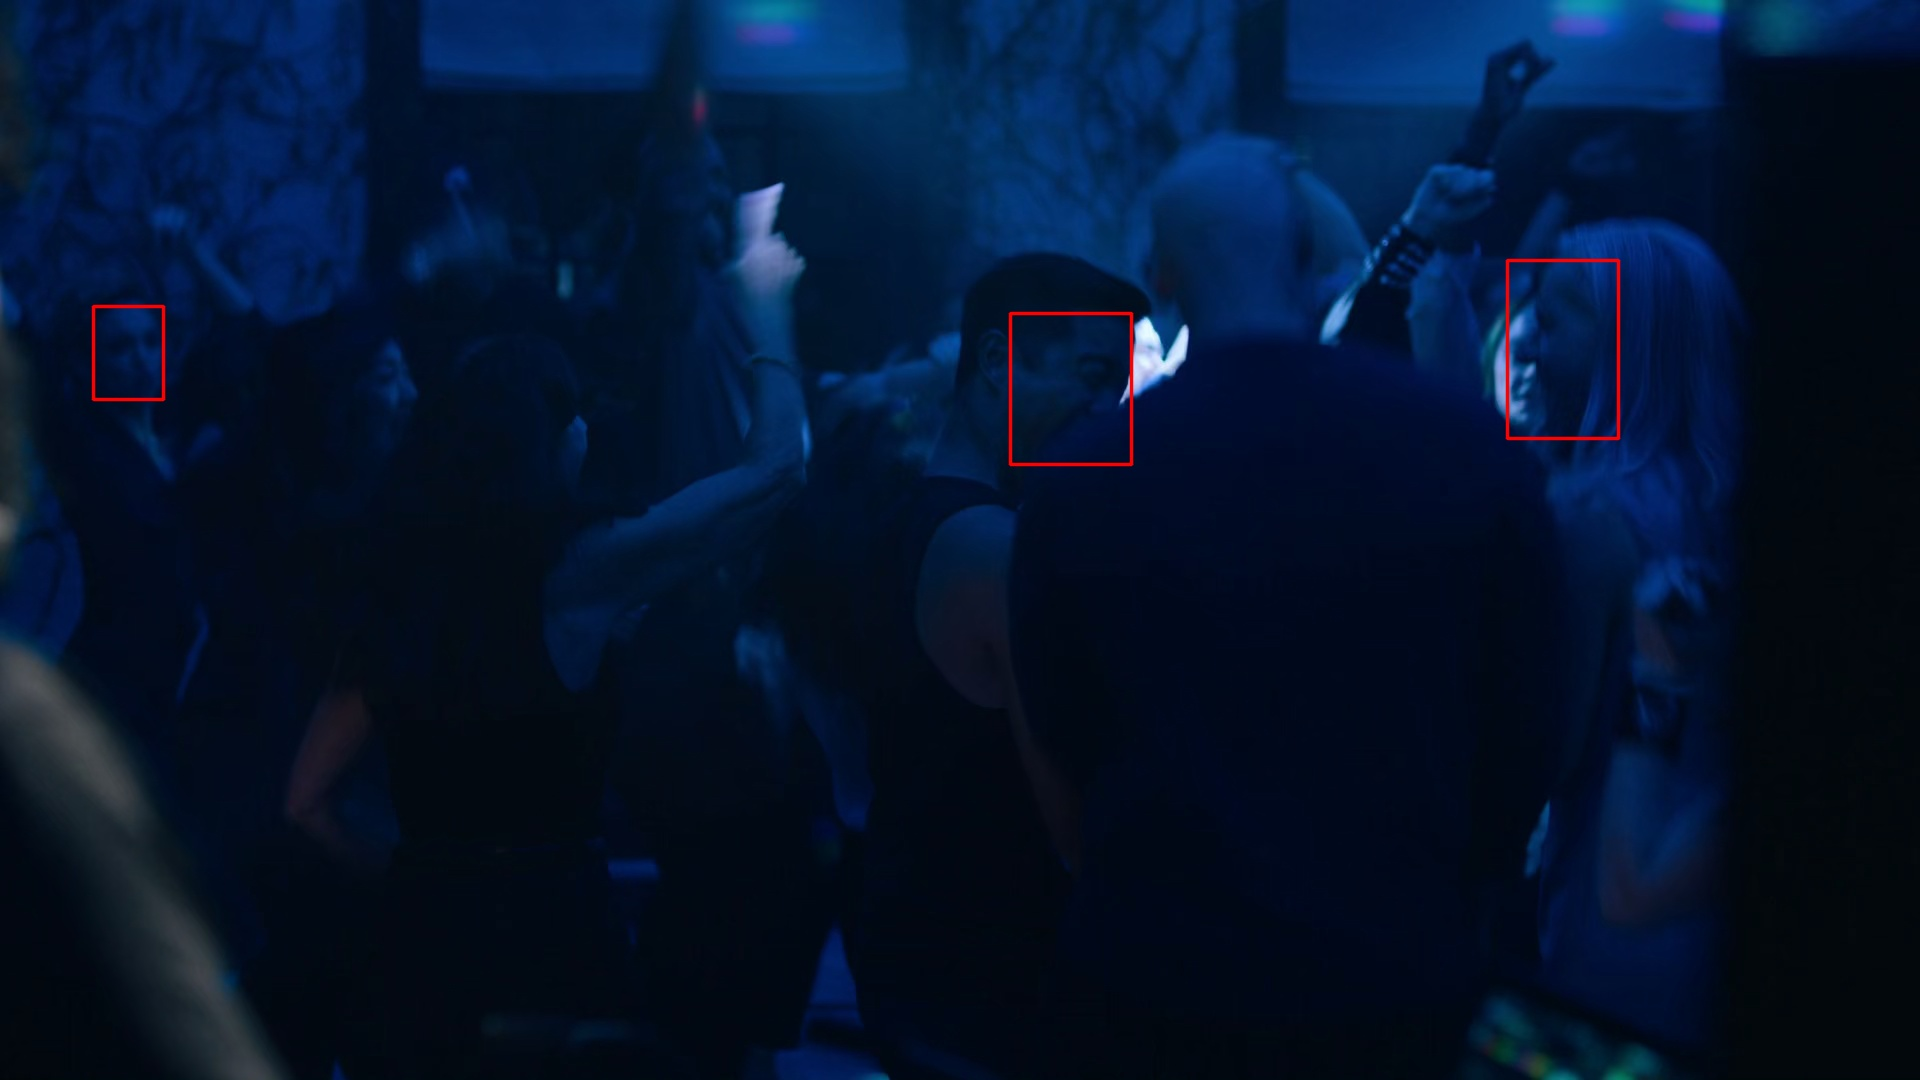

In [36]:
img = cv2.imread('../test_images/Billions.S06E10.1080p.WEBRip.x265-RARBG_73680.png')
faces = RetinaFace.detect_faces(img)
draw_faces(img, faces)

In [38]:
g = total_df[['name', 'pct_of_frame']].groupby('name').max()
g

,pct_of_frame
name,
Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,0.208669
Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,0.078935
Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,0.020561
Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,0.197761
Billions.S02E01.1080p.BluRay.x265-RARBG_32328.png,0.172855
...,...
Will.&.Grace.S11E17.New.Crib.1080p.Web.h264-JBee_28008.png,0.036285
fargo.s05e02.2160p.web.h265-successfulcrab-sample_0336.png,0.085892
fargo.s05e04.2160p.web.h265-successfulcrab_51600.png,0.129474


In [52]:
data = []
for idx, row in g.iterrows():
    temp = retina_df[retina_df['name'] == idx]
    rg = temp[['name', 'pct_of_frame']].groupby('name').max()
    if pd.isnull(row['pct_of_frame']) and pd.isnull(rg.iloc[0]['pct_of_frame']):
        datum = {'name': name,
                 'status': 'tn'}
        data.append(datum)
    elif not pd.isnull(row['pct_of_frame']) and pd.isnull(rg.iloc[0]['pct_of_frame']):
        datum = {'name': name,
                 'status': 'fn'}
        data.append(datum)
    elif pd.isnull(row['pct_of_frame']) and not pd.isnull(rg.iloc[0]['pct_of_frame']):
        datum = {'name': name,
                 'status': 'fp'}
        data.append(datum)
    elif not pd.isnull(row['pct_of_frame']) and not pd.isnull(rg.iloc[0]['pct_of_frame']):
        datum = {'name': name,
                 'status': 'tp'}
        data.append(datum)
top_df = pd.DataFrame(data)
top_df.head()
    

,name,status
0,The.X-Files.S01E10.Fallen.Angel.1080p.BluRay.1...,tp
1,The.X-Files.S01E10.Fallen.Angel.1080p.BluRay.1...,tp
2,The.X-Files.S01E10.Fallen.Angel.1080p.BluRay.1...,tp
3,The.X-Files.S01E10.Fallen.Angel.1080p.BluRay.1...,tp
4,The.X-Files.S01E10.Fallen.Angel.1080p.BluRay.1...,tp


In [53]:
top_df['status'].value_counts()

status
tp    944
tn     91
fn     18
fp     11
Name: count, dtype: int64

In [54]:
g.shape

(1064, 1)

In [55]:
top_df.shape

(1064, 2)

In [56]:
data = []
for idx, row in g.iterrows():
    temp = retina_df[retina_df['name'] == idx]
    rg = temp[['name', 'pct_of_frame']].groupby('name').max()
    if pd.isnull(row['pct_of_frame']) and pd.isnull(rg.iloc[0]['pct_of_frame']):
        status = 'tn'
    elif not pd.isnull(row['pct_of_frame']) and pd.isnull(rg.iloc[0]['pct_of_frame']):
        status = 'fn'
    elif pd.isnull(row['pct_of_frame']) and not pd.isnull(rg.iloc[0]['pct_of_frame']):
        status = 'fp'
    elif not pd.isnull(row['pct_of_frame']) and not pd.isnull(rg.iloc[0]['pct_of_frame']):
        status = 'tp'
    datum = {'name': name,
             'status': status}
    data.append(datum)
top_df = pd.DataFrame(data)
top_df.head()

,name,status
0,The.X-Files.S01E10.Fallen.Angel.1080p.BluRay.1...,tp
1,The.X-Files.S01E10.Fallen.Angel.1080p.BluRay.1...,tp
2,The.X-Files.S01E10.Fallen.Angel.1080p.BluRay.1...,tp
3,The.X-Files.S01E10.Fallen.Angel.1080p.BluRay.1...,tp
4,The.X-Files.S01E10.Fallen.Angel.1080p.BluRay.1...,tp


In [69]:
def accuracy(df, faces):
    data = []
    for name in faces['name'].unique().tolist():
        temp = df[df['name'] == name]
        eph = faces[faces['name'] == name]

        a_cnt = temp.shape[0]
        b_cnt = eph.shape[0]
        if pd.isnull(temp.iloc[0]['x1']) and pd.isnull(eph.iloc[0]['x1']):
            datum = {'name': name,
                    'status': 'tn'}
            data.append(datum)
        if a_cnt == b_cnt:
            for x in range(a_cnt):
                datum = {'name': name,
                        'status': 'tp'}
                data.append(datum)
        elif a_cnt > b_cnt:
            for x in range(a_cnt - b_cnt):
                datum = {'name': name,
                        'status': 'fp'}
                data.append(datum)
        elif b_cnt > a_cnt:
            for x in range(b_cnt - a_cnt):
                datum = {'name': name,
                        'status': 'fn'}
                data.append(datum)
    return pd.DataFrame(data)

In [66]:
def top1_accuracy(df, faces):
    g = faces[['name', 'pct_of_frame']].groupby('name').max()
    data = []
    for idx, row in g.iterrows():
        temp = df[df['name'] == idx]
        rg = temp[['name', 'pct_of_frame']].groupby('name').max()
        if pd.isnull(row['pct_of_frame']) and pd.isnull(rg.iloc[0]['pct_of_frame']):
            status = 'tn'
        elif not pd.isnull(row['pct_of_frame']) and pd.isnull(rg.iloc[0]['pct_of_frame']):
            status = 'fn'
        elif pd.isnull(row['pct_of_frame']) and not pd.isnull(rg.iloc[0]['pct_of_frame']):
            status = 'fp'
        elif not pd.isnull(row['pct_of_frame']) and not pd.isnull(rg.iloc[0]['pct_of_frame']):
            status = 'tp'
        datum = {'name': idx,
                'status': status}
        data.append(datum)
    return pd.DataFrame(data)

In [67]:
test_df = top1_accuracy(retina_df, total_df)
test_df.head()

,name,status
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,tp
1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,tp
2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,tp
3,Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,tp
4,Billions.S02E01.1080p.BluRay.x265-RARBG_32328.png,tp


In [63]:
test_df['status'].value_counts()

status
tp    944
tn     91
fn     18
fp     11
Name: count, dtype: int64

In [59]:
total_df.to_csv('../data/faces.csv')

In [70]:
df = accuracy(retina_df, total_df)
df.head()

,name,status
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,tp
1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,tp
2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,fp
3,Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,tp
4,Billions.S02E01.1080p.BluRay.x265-RARBG_32328.png,tp


In [71]:
df['status'].value_counts()

status
tp    1503
fp     158
tn      91
fn      50
Name: count, dtype: int64